I made modelling and nex step decisions and claude helped me quickly recode the model to run efficiently to get a new baseline

* Updated with features matching CMIP6 models
* Using fixed data

In [8]:
### Target: County-Level hourly MW

In [9]:
##!pip install shap lightgbm pandas pyarrow --quiet

In [10]:
### Cell 2 — Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import lightgbm as lgb
import shap
from sklearn.metrics import mean_squared_error
sns.set(style="darkgrid")

In [11]:
### Cell 3 — Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
### Cell 4 — Load Data
def read_file(filename):
    directory = '/content/drive/My Drive/210_capstone/final_datasets/full_hist_attr/'
    return pd.read_parquet(directory + filename + '.parquet')

In [13]:
df = read_file('full_data_18to23_asofFeb25_1')

In [17]:
df.columns

Index(['date', 'county', 'dpt_afternoon_k_pop', 'hdd65', 'wind_peak_ms_mean',
       'wind_low_ms_mean', 'spfh_peak_kgkg_pop', 'wind_peak_ms_pop', 'cdd75',
       'tavg_k', 'dpt_afternoon_k_mean', 'cloud_cover_pct_pop',
       'dpt_morning_k_mean', 'tmax_k_pop', 'cdd65_pop', 'cloud_cover_pct_mean',
       'tmin_k', 'hdd65_pop', 'dpt_morning_k_pop', 'wind_low_ms_pop',
       'trange_k', 'cdd65', 'tmin_k_pop', 'cdd75_pop', 'spfh_peak_kgkg_mean',
       'tmax_k', 'real_data_urma', 'staying_total', 'entering_total',
       'leaving_total', 'real_data_commuting', 'cuml_count', 'cuml_sq_foot',
       'cuml_utility_cap', 'cuml_dc_load', 'real_data_data_centers',
       'Total_Daily_Electricity_Usage', 'hour_of_max',
       'Max_Daily_Electricity_Usage', 'Public Level 1',
       'Shared Private Level 1', 'Public Level 2', 'Shared Private Level 2',
       'Public DC Fast', 'Shared Private DC Fast', 'Total',
       'real_data_ev_charging', 'bev', 'phev', 'fcev',
       'real_data_ev_poplution', 

In [38]:
### Cell 5 — Rename Columns
df = df.rename(columns={
    'Date':  'date',
    'County': 'county',
    'BEV':   'bev',
    'PHEV':  'phev',
    'FCEV':  'fcev',
    'Total_Daily_Electricity_Usage': 'electricity_usage',
    'Per_Capita_Personal_Income_Adjusted': 'est_median_income',
    'Total': 'total'
})

In [39]:
### Cell 6 — Target Engineering (BEFORE split)
df['date'] = pd.to_datetime(df['date'])
df['elec_per_capita']     = df['electricity_usage'] / df['total_pop']
df['elec_per_capita_log'] = np.log(df['elec_per_capita'])

target = 'elec_per_capita_log'

print(df.shape)
print(df['elec_per_capita'].describe())


(127078, 78)
count    127078.000000
mean          0.019337
std           0.003435
min           0.009952
25%           0.016952
50%           0.018485
75%           0.021243
max           0.042496
Name: elec_per_capita, dtype: float64


In [40]:
df["total_ev_pop"] = df["total"]/df["total_pop"]

In [41]:
ROLLING_SPECS = [
    ("cdd65_pop_roll5",       "cdd65_pop",  5,  "sum"),
    ("hdd65_pop_roll5",       "hdd65_pop",  5,  "sum"),
    ("tmax_k_pop_roll5_max",  "tmax_k_pop", 5,  "max"),
    ("tmax_k_pop_roll7_mean", "tmax_k_pop", 7,  "mean"),
]

def add_rolling_features(df):
    df = df.sort_values(["county", "date"]).copy()
    g = df.groupby("county", sort=False)
    for new_col, src_col, window, agg in ROLLING_SPECS:
        df[new_col] = g[src_col].transform(
            lambda x, w=window, a=agg: getattr(x.rolling(w, min_periods=1), a)()
        )
    return df

In [42]:
# Compute 2019 mobility baseline before dropping the columns
mobility_baseline = (
    df[df['date'].dt.year == 2019]
    .groupby(['county', 'day_of_week'])[['staying_total', 'entering_total', 'leaving_total']]
    .median()
    .reset_index()
)
print("Mobility baseline shape:", mobility_baseline.shape)


Mobility baseline shape: (406, 5)


In [43]:
df = add_rolling_features(df)

# Replace mobility with frozen 2019 baseline
df = df.drop(columns=['staying_total', 'entering_total', 'leaving_total'])
df = df.merge(mobility_baseline, on=['county', 'day_of_week'], how='left')


In [44]:
# Split
train_df = df[df['date'].dt.year <= 2021].copy()
val_df   = df[df['date'].dt.year == 2022].copy()
test_df  = df[df['date'].dt.year == 2023].copy()

print(f"Train: {train_df.shape}  ({train_df['date'].dt.year.min()}–{train_df['date'].dt.year.max()})")
print(f"Val:   {val_df.shape}")
print(f"Test:  {test_df.shape}")


Train: (84738, 79)  (2018–2021)
Val:   (21170, 79)
Test:  (21170, 79)


In [53]:
### Cell 8 — Features
selected_features = [
    # CATEGORICAL
    "county",
    "day_of_week",
    # CALENDAR
    "quarter",
    "month",
    "is_holiday",
    # TEMPERATURE
    "tmax_k_pop",
    "tmin_k_pop",
    "trange_k",
    # DEGREE DAYS
    "hdd65_pop",
    "cdd65_pop",
    "cdd75_pop",
    # ROLLING WEATHER
    "cdd65_pop_roll5",
    "hdd65_pop_roll5",
    "tmax_k_pop_roll5_max",
    "tmax_k_pop_roll7_mean",
    # HUMIDITY
    "spfh_peak_kgkg_pop",
    # WIND
    "wind_peak_ms_pop",
    # MOBILITY
    # "staying_total",
    # "entering_total",
    # "leaving_total",
    # DATA CENTERS
    "cuml_count",
    "cuml_sq_foot",
    "cuml_utility_cap",
    "cuml_dc_load",
    # EVs
    "bev",
    "phev",
    "fcev",
    # "total_ev_pop",
    # SOCIOECONOMIC
    "est_median_income",
    "total_pop",
]

cat_cols = ["county", "day_of_week"]
print(f"Features: {len(selected_features)}")

Features: 26


In [45]:
#selected_features=["month", "total_pop", "est_median_income", "cuml_utility_cap", "cdd65_pop", "hdd65_pop", "spfh_peak_kgkg_pop", "cloud_cover_pct_pop", "wind_low_ms_pop", "wind_peak_ms_pop", "total_ev_pop"]

In [54]:
cat_cols = ["county", "day_of_week"]
print(f"Features: {len(selected_features)}")

Features: 26


In [55]:
### Cell 9 — Train Model
def set_and_align_categories(train_df, val_df, cat_cols=cat_cols):
    for c in cat_cols:
        train_df[c] = train_df[c].astype("category")
        val_df[c]   = val_df[c].astype("category")
        val_df[c]   = val_df[c].cat.set_categories(train_df[c].cat.categories)
    return train_df, val_df

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def run_model(train_df, val_df, features, params):
    X_train, y_train = train_df[features], train_df[target]
    X_val,   y_val   = val_df[features],   val_df[target]

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train),
            (X_val,   y_val),],
        eval_names=["train","val"],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(period=300)]
    )

    preds_val = model.predict(X_val, num_iteration=model.best_iteration_)
    rmse_val  = rmse(y_val, preds_val)
    return model, rmse_val, preds_val, model.best_iteration_

params = dict(
    n_estimators=5000,
    learning_rate=0.02,
    num_leaves=64,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,      # L1 — add this
    reg_lambda=1.0,     # L2 — add this
    random_state=42,
)

train_df, val_df = set_and_align_categories(train_df, val_df)

model, rmse_val, preds_val, best_iter = run_model(train_df, val_df, selected_features, params)

print(f"""
rmse_val (log per capita): {rmse_val:.6f}
best_iter:                 {best_iter}
""")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.036464 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5442
[LightGBM] [Info] Number of data points in the train set: 84738, number of used features: 26
[LightGBM] [Info] Start training from score -3.972263
[300]	train's rmse: 0.0484143	train's l2: 0.00234394	val's rmse: 0.0744014	val's l2: 0.00553556
[600]	train's rmse: 0.0438009	train's l2: 0.00191851	val's rmse: 0.0713017	val's l2: 0.00508393
[900]	train's rmse: 0.041385	train's l2: 0.00171272	val's rmse: 0.0703761	val's l2: 0.00495279
[1200]	train's rmse: 0.039563	train's l2: 0.00156523	val's rmse: 0.0698556	val's l2: 0.0048798
[1500]	train's rmse: 0.0380566	train's l2: 0.0014483	val's rmse: 0.0695073	val's l2: 0.00483127
[1800]	train's rmse: 0.0368334	train's l2: 0.0013567	val's rmse: 0.0692839	val's l2: 0.00480026
[2100]	train's rmse: 0.0357462	train's l2: 0.00127779	val's rmse: 0.0691622	val's l

In [56]:
### Cell 10 — MWh Metrics
val_df = val_df.copy()
val_df['preds_mwh'] = np.exp(preds_val) * val_df['total_pop']

def rmse_mwh(df):
    return np.sqrt(mean_squared_error(df['electricity_usage'], df['preds_mwh']))

def pct_of_mean(df):
    return 100 * rmse_mwh(df) / df['electricity_usage'].mean()

def pop_weighted_rmse_pct(df):
    w = df['total_pop'].values
    wrmse = np.sqrt(np.sum(w * (df['electricity_usage'] - df['preds_mwh'])**2) / np.sum(w))
    wmean = np.average(df['electricity_usage'], weights=w)
    return 100 * wrmse / wmean

print(f"RMSE MWh:          {rmse_mwh(val_df):,.0f}")
print(f"RMSE % of mean:    {pct_of_mean(val_df):.1f}%")
print(f"Pop-wtd RMSE %:    {pop_weighted_rmse_pct(val_df):.1f}%")


RMSE MWh:          1,624
RMSE % of mean:    12.1%
Pop-wtd RMSE %:    7.2%


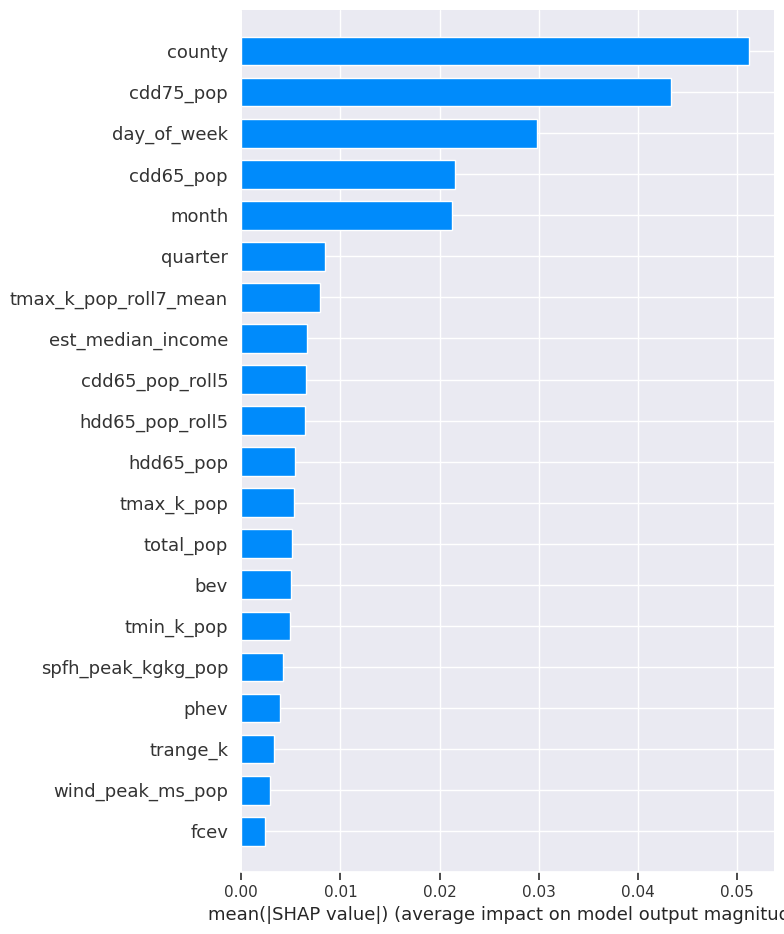

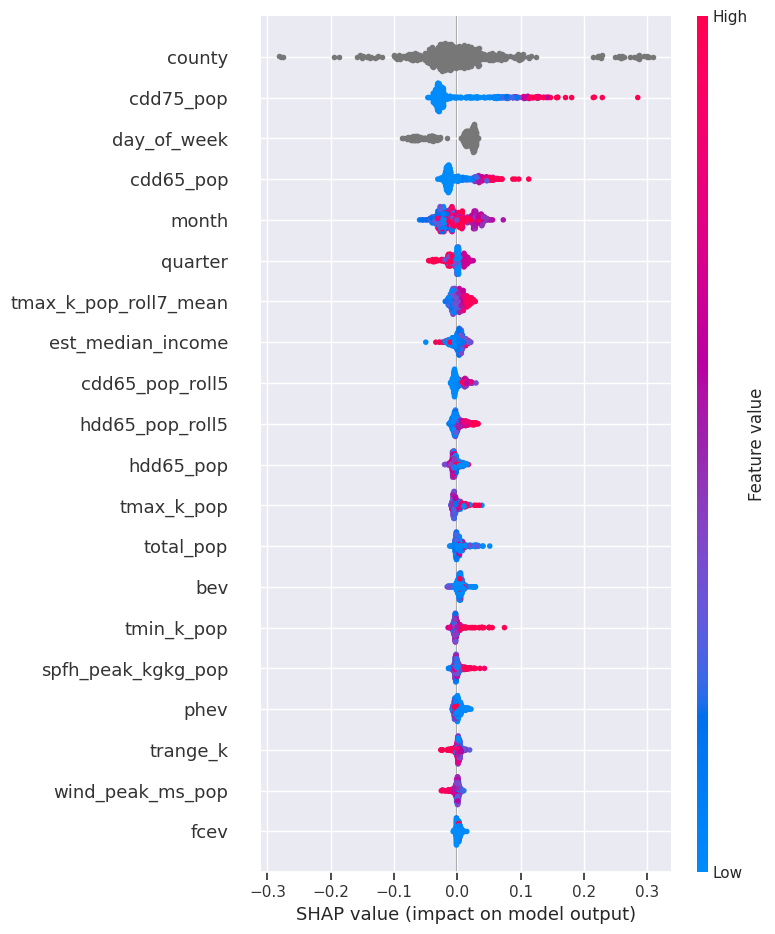

In [57]:
### Cell 11 — SHAP
explainer   = shap.TreeExplainer(model)
shap_sample = val_df[selected_features].sample(500, random_state=42)
shap_values = explainer.shap_values(shap_sample)

shap.summary_plot(shap_values, shap_sample, plot_type="bar")
shap.summary_plot(shap_values, shap_sample)


In [ ]:
#!pip install mlflow

In [58]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.0/811.0 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 13.4 MB/s eta 0:00:00


In [59]:
import mlflow
import mlflow.lightgbm
import joblib, os, tempfile
from datetime import datetime

run_ts        = datetime.now().strftime('%Y%m%d_%H%M')
model_version = 'v3'
model_name    = f'lgbm_{target}_{model_version}_{run_ts}'

MODEL_DIR = '/content/drive/My Drive/210_capstone/models'
PRED_DIR  = '/content/drive/My Drive/210_capstone/predictions'
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PRED_DIR,  exist_ok=True)

mlflow.set_tracking_uri(f'sqlite:///{MODEL_DIR}/mlflow.db')
mlflow.set_experiment('climate-feat-lgbm')

with mlflow.start_run(run_name=f'lgbm_v3_{target}'):

    # ── Params ────────────────────────────────────────────────────────────
    mlflow.log_params(params)
    mlflow.log_param('target',       target)
    mlflow.log_param('n_features',   len(selected_features))
    mlflow.log_param('best_iter',    best_iter)
    mlflow.log_param('run_ts',       run_ts)

    # ── Log-space RMSE ────────────────────────────────────────────────────
    mlflow.log_metric('rmse_log_val', rmse_val)

    # ── MWh metrics ───────────────────────────────────────────────────────
    mlflow.log_metric('rmse_mwh_val',        rmse_mwh(val_df))
    mlflow.log_metric('rmse_pct_mean_val',   pct_of_mean(val_df))
    mlflow.log_metric('pop_wtd_rmse_pct_val',pop_weighted_rmse_pct(val_df))

    # ── Log model ─────────────────────────────────────────────────────────
    mlflow.lightgbm.log_model(model, artifact_path='lgbm')

    # ── Feature list as artifact ──────────────────────────────────────────
    with tempfile.NamedTemporaryFile(mode='w', suffix='.txt', delete=False) as f:
        f.write('\n'.join(selected_features))
        tmp = f.name
    mlflow.log_artifact(tmp, artifact_path='metadata')
    os.unlink(tmp)

    print(f'MLflow run logged — climate-feat-lgbm / {model_name}')
    print(f'  rmse_mwh_val:         {rmse_mwh(val_df):,.0f} MWh')
    print(f'  pop_wtd_rmse_pct_val: {pop_weighted_rmse_pct(val_df):.1f}%')

# ── Export ────────────────────────────────────────────────────────────────────
joblib.dump(model,             f'{MODEL_DIR}/{model_name}.pkl')
joblib.dump(selected_features, f'{MODEL_DIR}/{model_name}_features.pkl')
mobility_baseline.to_parquet(  f'{MODEL_DIR}/mobility_baseline_2019.parquet')

val_df['elec_per_capita_log_actual'] = val_df[target]
val_df['elec_per_capita_log_pred']   = preds_val

pred_cols = ['county', 'date', 'total_pop', 'electricity_usage',
             'elec_per_capita_log_actual', 'elec_per_capita_log_pred', 'preds_mwh']
val_df[pred_cols].to_parquet(f'{PRED_DIR}/{model_name}_preds_val.parquet', index=False)

print(f'\nExported:')
print(f'  {model_name}.pkl')
print(f'  {model_name}_features.pkl')
print(f'  mobility_baseline_2019.parquet')
print(f'  {model_name}_preds_val.parquet')

2026/02/25 20:55:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/25 20:55:30 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow run logged — climate-feat-lgbm / lgbm_elec_per_capita_log_v3_20260225_2055
  rmse_mwh_val:         1,624 MWh
  pop_wtd_rmse_pct_val: 7.2%

Exported:
  lgbm_elec_per_capita_log_v3_20260225_2055.pkl
  lgbm_elec_per_capita_log_v3_20260225_2055_features.pkl
  mobility_baseline_2019.parquet
  lgbm_elec_per_capita_log_v3_20260225_2055_preds_val.parquet
